In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dhrubangtalukdar/telco-customer-churn-data/synthetic_customer_churn_100k.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dhrubangtalukdar/telco-customer-churn-data/synthetic_customer_churn_100k.csv


In [3]:
import os
import pandas as pd

# 1. Automatically look inside /kaggle/input and find any .csv files
csv_files = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            csv_files.append(os.path.join(dirname, filename))

# 2. Print what we found and load the first one automatically
if csv_files:
    print(f"Success! Found file at path: {csv_files[0]}")
    df = pd.read_csv(csv_files[0])
    print("\n--- Data Structure ---")
    df.info()
else:
    print("No CSV files found. Please make sure the dataset is added properly.")

Success! Found file at path: /kaggle/input/datasets/dhrubangtalukdar/telco-customer-churn-data/synthetic_customer_churn_100k.csv

--- Data Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


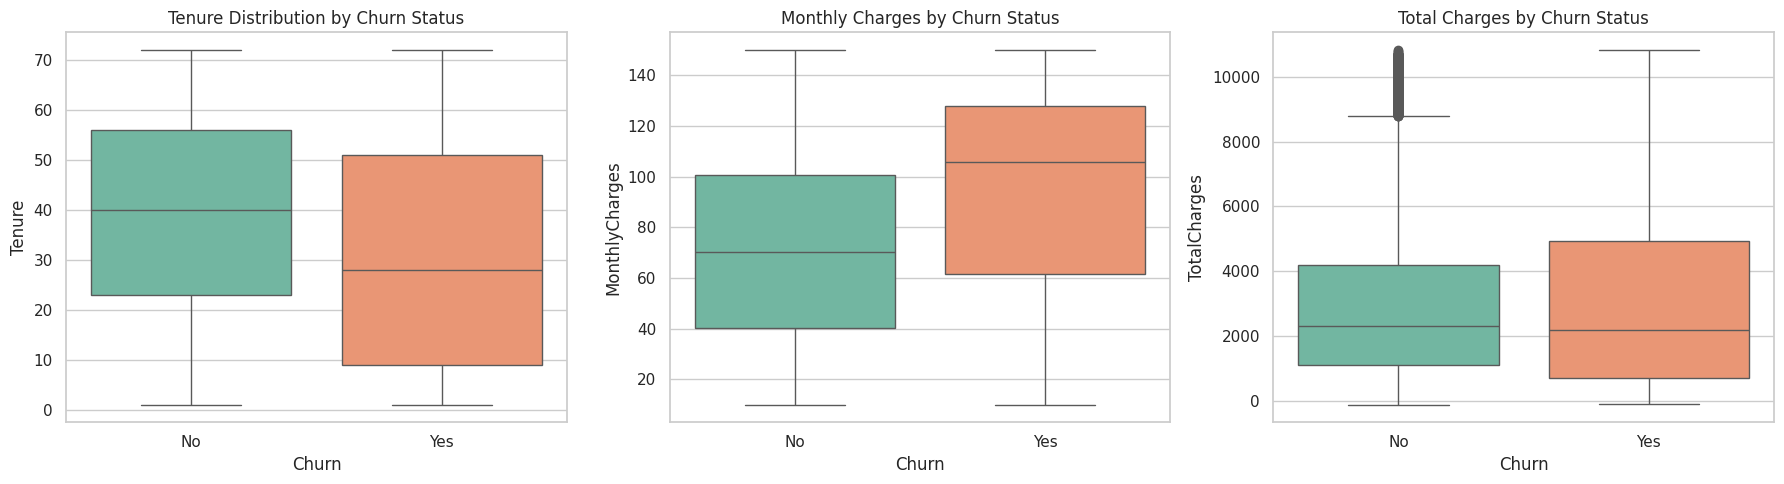

In [4]:
import warnings
# Silence all future warnings globally to keep the notebook clean
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set_theme(style="whitegrid")

# Create side-by-side plots for numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tenure vs Churn
sns.boxplot(x='Churn', y='Tenure', data=df, ax=axes[0], hue='Churn', legend=False, palette='Set2')
axes[0].set_title('Tenure Distribution by Churn Status')

# 2. Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], hue='Churn', legend=False, palette='Set2')
axes[1].set_title('Monthly Charges by Churn Status')

# 3. Total Charges vs Churn
sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], hue='Churn', legend=False, palette='Set2')
axes[2].set_title('Total Charges by Churn Status')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Separate features and target variable
# Drop CustomerID (not useful for prediction) and Churn (the target)
X = df.drop(columns=['CustomerID', 'Churn'])

# Convert target label 'Yes'/'No' to binary integers 1/0
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Identify structural feature types
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = ['Gender', 'Contract', 'PaymentMethod']

# 3. Create a preprocessing configuration
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

# 4. Perform stratified train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Fit the preprocessor on training data and transform both sets
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("Data successfully split and transformed!")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape:  {X_test_scaled.shape}")

Data successfully split and transformed!
Training set shape: (80000, 11)
Testing set shape:  (20000, 11)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, classification_report

# 1. Initialize the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# 2. Iterate, train, and evaluate each baseline model
for name, model in models.items():
    # Fit the model on the preprocessed training matrices
    model.fit(X_train_scaled, y_train)
    
    # Generate binary predictions (0 or 1)
    y_pred = model.predict(X_test_scaled)
    
    # Generate continuous probabilities for the positive class (needed for ROC-AUC)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"======= {name} =======")
    print(f"Accuracy : {acc:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"ROC-AUC  : {auc:.4f}\n")

======= Logistic Regression =======
Accuracy : 0.7234
Recall   : 0.4660
ROC-AUC  : 0.7719

======= Random Forest =======
Accuracy : 0.7316
Recall   : 0.5070
ROC-AUC  : 0.7877

======= XGBoost =======
Accuracy : 0.7528
Recall   : 0.5390
ROC-AUC  : 0.8002



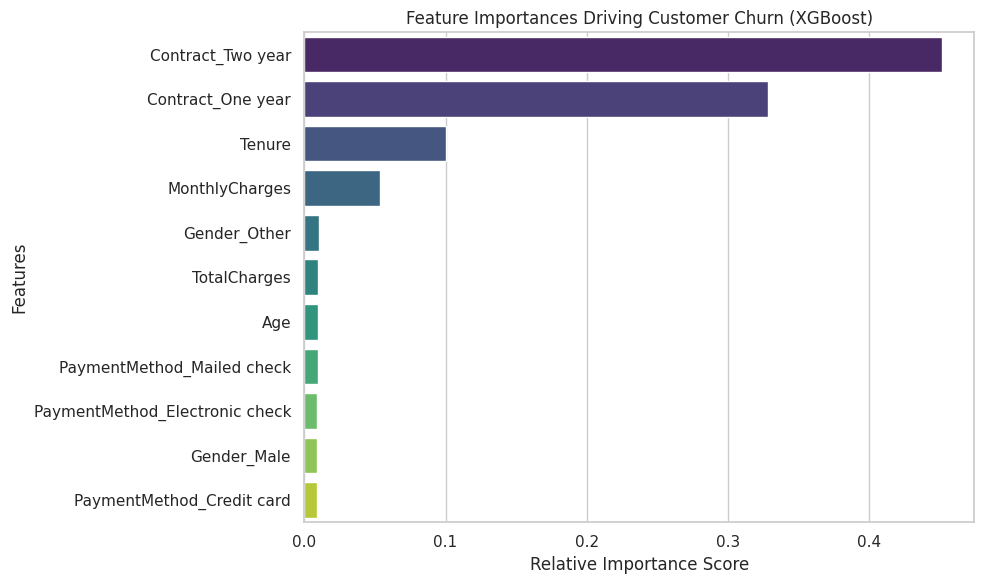

In [7]:
import numpy as np

# Extract the feature names after one-hot encoding
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_features = num_cols + encoded_cat_cols

# Grab the feature importances from the trained XGBoost model
# (Make sure the previous cell has fully finished running XGBoost first!)
importances = models['XGBoost'].feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[all_features[i] for i in indices], palette='viridis')
plt.title('Feature Importances Driving Customer Churn (XGBoost)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

#Telco_Customer_Churn_Prediction